# Off-Grid Microgrid Dispatch Model
### Islanded Event Microgrid: Solar PV + Li-Ion Battery + Hydrogen Fuel Cell

Simulates a 24-hour off-grid microgrid powering an isolated event. A dispatch algorithm minimises operational costs while avoiding blackouts via an extreme Value of Lost Load (VoLL) penalty.

**Architecture:**
1. Dependencies & Global Configuration
2. Stochastic Environment Simulators (Load & Solar)
3. Physical Asset Object Models
4. Dispatch Engine (Rule-Based Optimiser)
5. Visualisations & Stress Testing

---
## Section 1 — Dependencies & Global Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import linprog
from dataclasses import dataclass, field
from typing import NamedTuple

sns.set_theme(style='darkgrid', palette='muted')
rng = np.random.default_rng(seed=42)

In [2]:
# ── Time grid ────────────────────────────────────────────────────────────────
DT_MIN   = 1           # time step [minutes]
DT_HR    = DT_MIN / 60 # time step [hours]
N_STEPS  = 24 * 60     # 1 440 minutes in 24 hours
T        = np.linspace(0, 24, N_STEPS, endpoint=False)  # hours axis

# ── Economic parameters ───────────────────────────────────────────────────────
VOLL            = 10_000   # Value of Lost Load   [USD / kWh]
COST_BATT_DEG   = 0.05     # Battery degradation  [USD / kWh cycled]
COST_H2_FC      = 0.10     # Fuel cell dispatch   [USD / kWh out]
COST_H2_EL      = 0.02     # Electrolyser run     [USD / kWh in]

# ── Solar PV parameters ───────────────────────────────────────────────────────
SOLAR_CAPACITY_KW = 150    # Nameplate capacity
SOLAR_PEAK_HOUR   = 13.0   # Solar noon [hour]
SOLAR_WIDTH       = 5.0    # Half-width of Gaussian clear-sky envelope [hours]

# ── Battery parameters ────────────────────────────────────────────────────────
BATT_CAPACITY_KWH = 200
BATT_MAX_KW       = 100
BATT_EFF          = 0.92
BATT_SOC_MIN      = 0.10
BATT_SOC_MAX      = 0.95
BATT_SOC_INIT     = 0.50

# ── Hydrogen system parameters ────────────────────────────────────────────────
H2_TANK_KWH       = 500
H2_FC_MAX_KW      = 80
H2_EL_MAX_KW      = 60
H2_FC_EFF         = 0.60
H2_EL_EFF         = 0.70
H2_LOH_MIN        = 0.05
H2_LOH_MAX        = 0.95
H2_LOH_INIT       = 0.20

# ── Load parameters ───────────────────────────────────────────────────────────
LOAD_PEAK_KW      = 120
LOAD_BASE_KW      = 40
LOAD_KAPPA        = 0.3
LOAD_SIGMA        = 8.0

# ── Cloud process parameters ──────────────────────────────────────────────────
CLOUD_KAPPA       = 0.05
CLOUD_THETA       = 0.85
CLOUD_SIGMA       = 0.18

print('Configuration loaded.')
print(f'  Simulation horizon : {N_STEPS} steps ({N_STEPS * DT_MIN} minutes)')
print(f'  VoLL               : ${VOLL:,.0f} / kWh')

Configuration loaded.
  Simulation horizon : 1440 steps (1440 minutes)
  VoLL               : $10,000 / kWh


---
## Section 2 — Stochastic Environment Simulators

### 2.1 Event Load — Ornstein–Uhlenbeck process
$$dL_t = \kappa_L(\theta_L(t) - L_t)\,dt + \sigma_L\,dW_{t,L}$$

### 2.2 Solar Irradiance — Bounded stochastic cloud cover
$$dC_t = \kappa_C(\theta_C - C_t)\,dt + \sigma_C\sqrt{C_t(1-C_t)}\,dW_{t,C}$$
$$P_{\text{solar}}(t) = P_{\max} \cdot G_{\text{clear}}(t) \cdot C_t$$

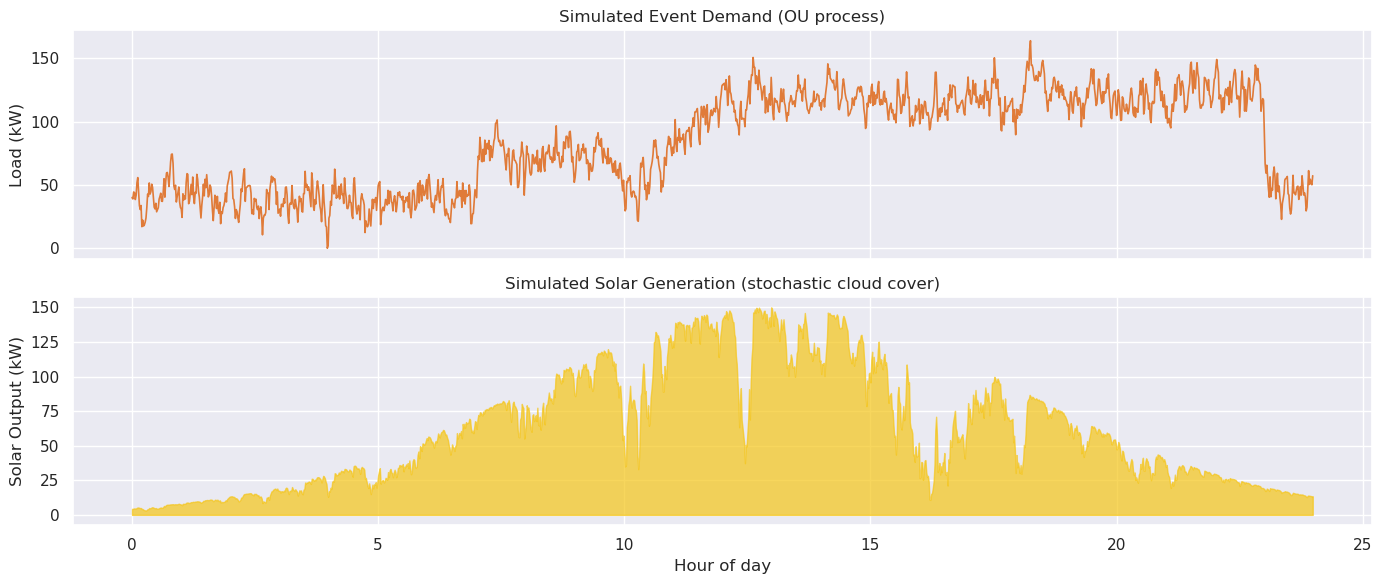

In [3]:
def _baseline_load(t_hours: np.ndarray, peak_kw: float, base_kw: float) -> np.ndarray:
    """Deterministic event schedule: ramp-up, peak during show, overnight base."""
    load = np.full_like(t_hours, base_kw)
    mask_setup = (t_hours >= 7) & (t_hours < 10)
    load[mask_setup] = base_kw + (peak_kw - base_kw) * 0.4
    mask_event = (t_hours >= 10) & (t_hours < 23)
    ramp = np.clip((t_hours[mask_event] - 10) / 2, 0, 1)
    load[mask_event] = base_kw + (peak_kw - base_kw) * ramp
    return load


def generate_event_load(
    peak_demand: float = LOAD_PEAK_KW,
    volatility:  float = LOAD_SIGMA,
    kappa:       float = LOAD_KAPPA,
    rng: np.random.Generator = rng,
) -> np.ndarray:
    """Simulate 1-minute load via Euler-Maruyama discretisation of OU process."""
    theta = _baseline_load(T, peak_demand, LOAD_BASE_KW)
    L = np.empty(N_STEPS)
    L[0] = theta[0]
    dW = rng.standard_normal(N_STEPS) * np.sqrt(DT_MIN)
    for i in range(1, N_STEPS):
        L[i] = L[i-1] + kappa * (theta[i] - L[i-1]) * DT_MIN + volatility * dW[i]
    return np.clip(L, 0, None)


def _clear_sky_envelope(t_hours: np.ndarray, capacity_kw: float) -> np.ndarray:
    return capacity_kw * np.exp(-0.5 * ((t_hours - SOLAR_PEAK_HOUR) / SOLAR_WIDTH) ** 2)


def generate_solar_profile(
    array_capacity: float = SOLAR_CAPACITY_KW,
    cloudiness:     float = 1 - CLOUD_THETA,
    cloud_sigma:    float = CLOUD_SIGMA,
    rng: np.random.Generator = rng,
) -> np.ndarray:
    """Simulate solar output via bounded stochastic cloud-cover process."""
    theta_c = 1.0 - cloudiness
    C = np.empty(N_STEPS)
    C[0] = theta_c
    dW = rng.standard_normal(N_STEPS) * np.sqrt(DT_MIN)
    for i in range(1, N_STEPS):
        diffusion = cloud_sigma * np.sqrt(max(C[i-1] * (1 - C[i-1]), 1e-6))
        C[i] = C[i-1] + CLOUD_KAPPA * (theta_c - C[i-1]) * DT_MIN + diffusion * dW[i]
        C[i] = np.clip(C[i], 0.0, 1.0)
    G_clear = _clear_sky_envelope(T, array_capacity)
    return G_clear * C


# Quick preview
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
_L = generate_event_load(rng=np.random.default_rng(0))
_S = generate_solar_profile(rng=np.random.default_rng(0))
axes[0].plot(T, _L, color='#e07b39', lw=1.2)
axes[0].set_ylabel('Load (kW)')
axes[0].set_title('Simulated Event Demand (OU process)')
axes[1].fill_between(T, _S, alpha=0.7, color='#f5c518')
axes[1].set_ylabel('Solar Output (kW)')
axes[1].set_xlabel('Hour of day')
axes[1].set_title('Simulated Solar Generation (stochastic cloud cover)')
plt.tight_layout()
plt.show()

---
## Section 3 — Physical Asset Object Models

In [4]:
@dataclass
class BatteryStorage:
    """Li-Ion battery with asymmetric charge/discharge efficiency."""
    capacity_kwh:    float = BATT_CAPACITY_KWH
    max_kw:          float = BATT_MAX_KW
    efficiency:      float = BATT_EFF
    degradation_cost: float = COST_BATT_DEG
    soc_min:         float = BATT_SOC_MIN
    soc_max:         float = BATT_SOC_MAX
    soc:             float = field(default=BATT_SOC_INIT)

    def step(self, power_kw: float, dt_hours: float) -> float:
        """Apply requested power (positive=discharge, negative=charge). Returns actual kW."""
        power_kw = np.clip(power_kw, -self.max_kw, self.max_kw)
        if power_kw >= 0:  # discharging
            delta_soc = -(power_kw * dt_hours / self.efficiency) / self.capacity_kwh
        else:              # charging
            delta_soc = (-power_kw * dt_hours * self.efficiency) / self.capacity_kwh
        new_soc = np.clip(self.soc + delta_soc, self.soc_min, self.soc_max)
        actual_delta = new_soc - self.soc
        if power_kw >= 0:
            actual_power = -(actual_delta * self.capacity_kwh * self.efficiency) / dt_hours
        else:
            actual_power = (actual_delta * self.capacity_kwh / self.efficiency) / dt_hours
        self.soc = new_soc
        return actual_power

    @property
    def available_discharge_kwh(self) -> float:
        return (self.soc - self.soc_min) * self.capacity_kwh * self.efficiency

    @property
    def available_charge_kwh(self) -> float:
        return (self.soc_max - self.soc) * self.capacity_kwh / self.efficiency


@dataclass
class HydrogenSystem:
    """Electrolyser + compressed H2 tank + fuel cell system."""
    tank_kwh:   float = H2_TANK_KWH
    fc_max_kw:  float = H2_FC_MAX_KW
    el_max_kw:  float = H2_EL_MAX_KW
    fc_eff:     float = H2_FC_EFF
    el_eff:     float = H2_EL_EFF
    loh_min:    float = H2_LOH_MIN
    loh_max:    float = H2_LOH_MAX
    loh:        float = field(default=H2_LOH_INIT)

    def dispatch_fc(self, request_kw: float, dt_hours: float) -> float:
        """Discharge fuel cell. Returns actual power delivered."""
        request_kw = np.clip(request_kw, 0, self.fc_max_kw)
        h2_consumed  = (request_kw / self.fc_eff) * dt_hours
        max_h2       = (self.loh - self.loh_min) * self.tank_kwh
        actual_h2    = min(h2_consumed, max_h2)
        self.loh    -= actual_h2 / self.tank_kwh
        return actual_h2 * self.fc_eff / dt_hours

    def dispatch_el(self, request_kw: float, dt_hours: float) -> float:
        """Run electrolyser. Returns actual power consumed."""
        request_kw  = np.clip(request_kw, 0, self.el_max_kw)
        h2_produced  = request_kw * self.el_eff * dt_hours
        space        = (self.loh_max - self.loh) * self.tank_kwh
        actual_h2    = min(h2_produced, space)
        self.loh    += actual_h2 / self.tank_kwh
        return (actual_h2 / self.el_eff) / dt_hours

    @property
    def available_kwh(self) -> float:
        return (self.loh - self.loh_min) * self.tank_kwh * self.fc_eff


print('Asset classes defined: BatteryStorage, HydrogenSystem')

Asset classes defined: BatteryStorage, HydrogenSystem


---
## Section 4 — Dispatch Engine

### Objective (per step)
$$\min \sum_{k=0}^{H} \left[ C_{\text{batt}} |P_{\text{batt}}(k)| + C_{\text{fc}} P_{\text{fc}}(k) + C_{\text{el}} P_{\text{el}}(k) + \text{VoLL} \cdot P_{\text{unmet}}(k) \right]$$

**Priority stack (cost-ordered greedy heuristic):**
1. Solar serves load directly (free).
2. Battery absorbs surplus / covers deficit (cheap, fast).
3. Electrolyser stores excess when battery near-full.
4. Fuel cell backs up battery when SoC approaches minimum.
5. Curtailment of irrecoverable surplus.
6. Unmet load triggers VoLL penalty.

In [5]:
class DispatchRecord(NamedTuple):
    p_solar:   float
    p_batt:    float   # positive = discharge
    p_fc:      float
    p_el:      float
    p_curtail: float
    p_unmet:   float
    soc:       float
    loh:       float
    cost:      float


def dispatch_step(
    net_load: float,
    battery:  BatteryStorage,
    hydrogen: HydrogenSystem,
    p_solar:  float,
    load:     float,
) -> DispatchRecord:
    p_batt = p_fc = p_el = p_curtail = p_unmet = 0.0

    if net_load <= 0:
        # Excess energy
        surplus = -net_load
        to_batt = min(surplus, battery.available_charge_kwh / DT_HR, battery.max_kw)
        battery.step(-to_batt, DT_HR)
        p_batt   = -to_batt
        surplus -= to_batt
        if surplus > 1e-3:
            p_el     = hydrogen.dispatch_el(surplus, DT_HR)
            surplus -= p_el
        p_curtail = max(surplus, 0.0)
    else:
        # Energy deficit
        deficit  = net_load
        to_draw  = min(deficit, battery.available_discharge_kwh / DT_HR, battery.max_kw)
        p_batt   = battery.step(to_draw, DT_HR)
        deficit -= p_batt
        if deficit > 1e-3:
            p_fc     = hydrogen.dispatch_fc(deficit, DT_HR)
            deficit -= p_fc
        p_unmet = max(deficit, 0.0)

    cost = (COST_BATT_DEG * abs(p_batt) * DT_HR
            + COST_H2_FC  * p_fc        * DT_HR
            + COST_H2_EL  * p_el        * DT_HR
            + VOLL        * p_unmet     * DT_HR)

    return DispatchRecord(
        p_solar=p_solar, p_batt=p_batt, p_fc=p_fc,
        p_el=p_el, p_curtail=p_curtail, p_unmet=p_unmet,
        soc=battery.soc, loh=hydrogen.loh, cost=cost,
    )


def run_simulation(
    load_profile:  np.ndarray,
    solar_profile: np.ndarray,
    battery:       BatteryStorage | None = None,
    hydrogen:      HydrogenSystem | None = None,
) -> pd.DataFrame:
    batt = battery  if battery  is not None else BatteryStorage()
    h2   = hydrogen if hydrogen is not None else HydrogenSystem()
    records = []
    for i in range(N_STEPS):
        net = load_profile[i] - solar_profile[i]
        rec = dispatch_step(net, batt, h2, solar_profile[i], load_profile[i])
        records.append(rec)
    df = pd.DataFrame(records, columns=DispatchRecord._fields)
    df['load']   = load_profile
    df['time']   = T
    df['minute'] = np.arange(N_STEPS)
    return df


print('Dispatch engine ready.')

Dispatch engine ready.


---
## Section 5 — Visualisations & Stress Testing

In [6]:
def plot_results(df: pd.DataFrame, title: str = '') -> None:
    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)
    t   = df['time']

    # Plot 1: Stacked energy balance
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t, df['load'], color='#e07b39', lw=2, label='Load', zorder=5)
    ax1.stackplot(
        t,
        df['p_solar'].clip(lower=0),
        df['p_batt'].clip(lower=0),
        df['p_fc'],
        df['p_unmet'],
        labels=['Solar', 'Battery (discharge)', 'Fuel Cell', 'Unmet Load'],
        colors=['#f5c518', '#5bc0eb', '#6aaa64', '#e63946'],
        alpha=0.85,
    )
    ax1.fill_between(t, -df['p_batt'].clip(upper=0), 0,
                     color='#a8dadc', alpha=0.6, label='Battery (charge)')
    ax1.fill_between(t, -df['p_el'], 0,
                     color='#457b9d', alpha=0.6, label='Electrolyser')
    ax1.fill_between(t, -df['p_curtail'], 0,
                     color='#adb5bd', alpha=0.5, label='Curtailed')
    ax1.set_ylabel('Power (kW)')
    ax1.set_title('24-Hour Energy Balance')
    ax1.legend(loc='upper left', fontsize=8, ncol=4)
    ax1.axhline(0, color='white', lw=0.8, ls='--')

    # Plot 2: State of Charge tracker
    ax2  = fig.add_subplot(gs[1])
    ax2b = ax2.twinx()
    l1,  = ax2.plot(t,  df['soc'] * 100, color='#5bc0eb', lw=2, label='Battery SoC (%)')
    l2,  = ax2b.plot(t, df['loh'] * 100, color='#6aaa64', lw=2, ls='--', label='H2 Tank Level (%)')
    ax2.axhline(BATT_SOC_MIN * 100, color='#5bc0eb', lw=0.8, ls=':', alpha=0.7)
    ax2.axhline(BATT_SOC_MAX * 100, color='#5bc0eb', lw=0.8, ls=':', alpha=0.7)
    ax2b.axhline(H2_LOH_MIN * 100,  color='#6aaa64', lw=0.8, ls=':', alpha=0.7)
    ax2.set_ylabel('Battery SoC (%)', color='#5bc0eb')
    ax2b.set_ylabel('H2 Tank Level (%)', color='#6aaa64')
    ax2.set_ylim(0, 105)
    ax2b.set_ylim(0, 105)
    ax2.set_title('Asset State Tracker')
    ax2.legend(handles=[l1, l2], loc='upper right', fontsize=9)

    # Plot 3: Per-step cost
    ax3 = fig.add_subplot(gs[2])
    op_cost  = (COST_BATT_DEG * df['p_batt'].abs() * DT_HR
                + COST_H2_FC * df['p_fc'] * DT_HR
                + COST_H2_EL * df['p_el'] * DT_HR)
    voll_cost = VOLL * df['p_unmet'] * DT_HR
    ax3.bar(t, op_cost,   width=DT_HR, color='#457b9d', label='Operating cost', alpha=0.9)
    ax3.bar(t, voll_cost, width=DT_HR, color='#e63946', label='VoLL penalty',   alpha=0.9,
            bottom=op_cost)
    ax3.set_xlabel('Hour of day')
    ax3.set_ylabel('Cost (USD)')
    ax3.set_title('Per-Minute Cost Breakdown')
    ax3.legend(fontsize=9)

    for ax in [ax1, ax2, ax3]:
        ax.set_xlim(0, 24)
        ax.set_xticks(range(0, 25, 2))

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.show()


def financial_summary(df: pd.DataFrame, scenario_name: str = '') -> dict:
    batt_deg  = COST_BATT_DEG * df['p_batt'].abs().sum() * DT_HR
    fc_cost   = COST_H2_FC   * df['p_fc'].sum() * DT_HR
    el_cost   = COST_H2_EL   * df['p_el'].sum() * DT_HR
    voll_pen  = VOLL         * df['p_unmet'].sum() * DT_HR
    total     = batt_deg + fc_cost + el_cost + voll_pen
    curtailed = df['p_curtail'].sum() * DT_HR
    unmet_kwh = df['p_unmet'].sum() * DT_HR
    blackout_min = (df['p_unmet'] > 0.1).sum()

    print(f"\n{'='*55}")
    print(f"  FINANCIAL SUMMARY  —  {scenario_name}")
    print(f"{'='*55}")
    print(f"  Battery degradation cost  : ${batt_deg:>10,.2f}")
    print(f"  Fuel cell dispatch cost   : ${fc_cost:>10,.2f}")
    print(f"  Electrolyser run cost     : ${el_cost:>10,.2f}")
    print(f"  {'─'*44}")
    print(f"  Subtotal operating cost   : ${batt_deg+fc_cost+el_cost:>10,.2f}")
    print(f"  VoLL penalty (blackouts)  : ${voll_pen:>10,.2f}")
    print(f"  {'='*44}")
    print(f"  TOTAL COST                : ${total:>10,.2f}")
    print(f"  {'─'*44}")
    print(f"  Energy curtailed          : {curtailed:>10.2f} kWh")
    print(f"  Unmet energy (blackout)   : {unmet_kwh:>10.2f} kWh")
    print(f"  Blackout minutes          : {blackout_min:>10d} min")
    print(f"{'='*55}\n")

    return dict(
        scenario=scenario_name, total_cost=total,
        batt_deg=batt_deg, fc_cost=fc_cost, el_cost=el_cost,
        voll_penalty=voll_pen, curtailed_kwh=curtailed,
        unmet_kwh=unmet_kwh, blackout_minutes=blackout_min,
    )


print('Plotting and reporting helpers ready.')

Plotting and reporting helpers ready.


---
### Scenario A — Perfect Summer Day

High solar, predictable load. Battery fills by noon; electrolyser runs through afternoon; system coasts overnight on stored energy.

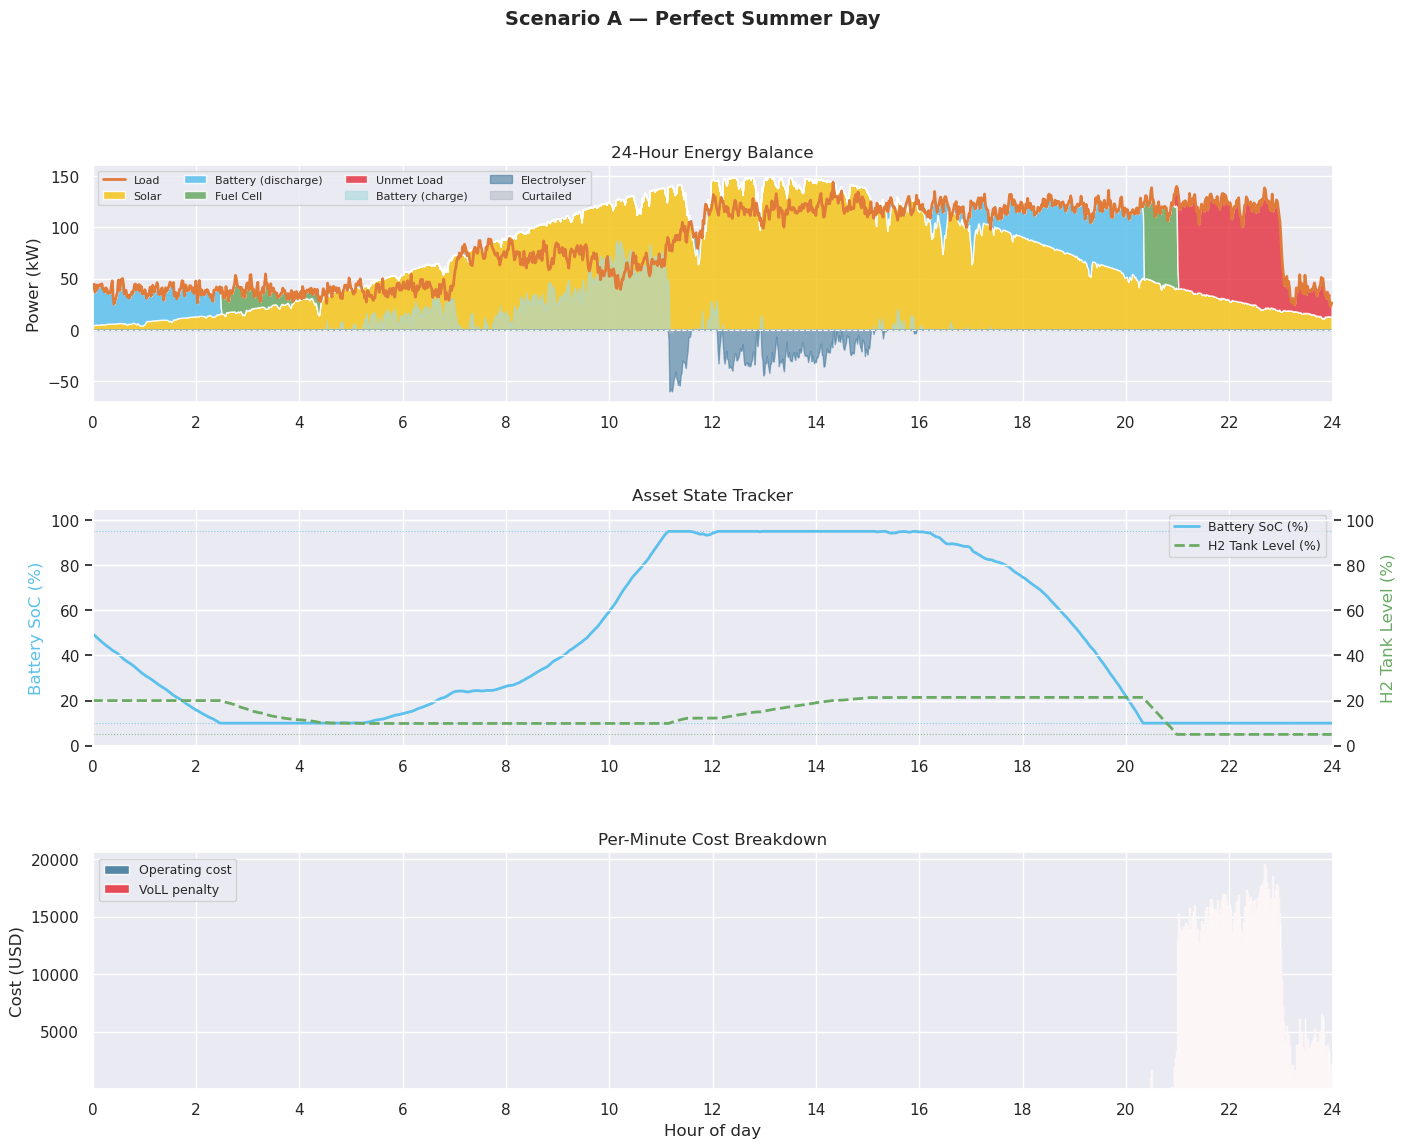


  FINANCIAL SUMMARY  —  Scenario A
  Battery degradation cost  : $     21.76
  Fuel cell dispatch cost   : $      7.97
  Electrolyser run cost     : $      1.65
  ────────────────────────────────────────────
  Subtotal operating cost   : $     31.38
  VoLL penalty (blackouts)  : $2,114,809.13
  TOTAL COST                : $2,114,840.51
  ────────────────────────────────────────────
  Energy curtailed          :       0.11 kWh
  Unmet energy (blackout)   :     211.48 kWh
  Blackout minutes          :        190 min



In [7]:
rng_a   = np.random.default_rng(1)
load_a  = generate_event_load(peak_demand=LOAD_PEAK_KW, volatility=5.0, rng=rng_a)
solar_a = generate_solar_profile(array_capacity=SOLAR_CAPACITY_KW, cloudiness=0.05, rng=rng_a)

df_a     = run_simulation(load_a, solar_a)
plot_results(df_a, 'Scenario A — Perfect Summer Day')
summary_a = financial_summary(df_a, 'Scenario A')

---
### Scenario B — Stormy Festival

Sudden cloud drops, elevated peak demand. Battery acts as a short-duration shock absorber; fuel cell triggers early to preserve battery baseline.

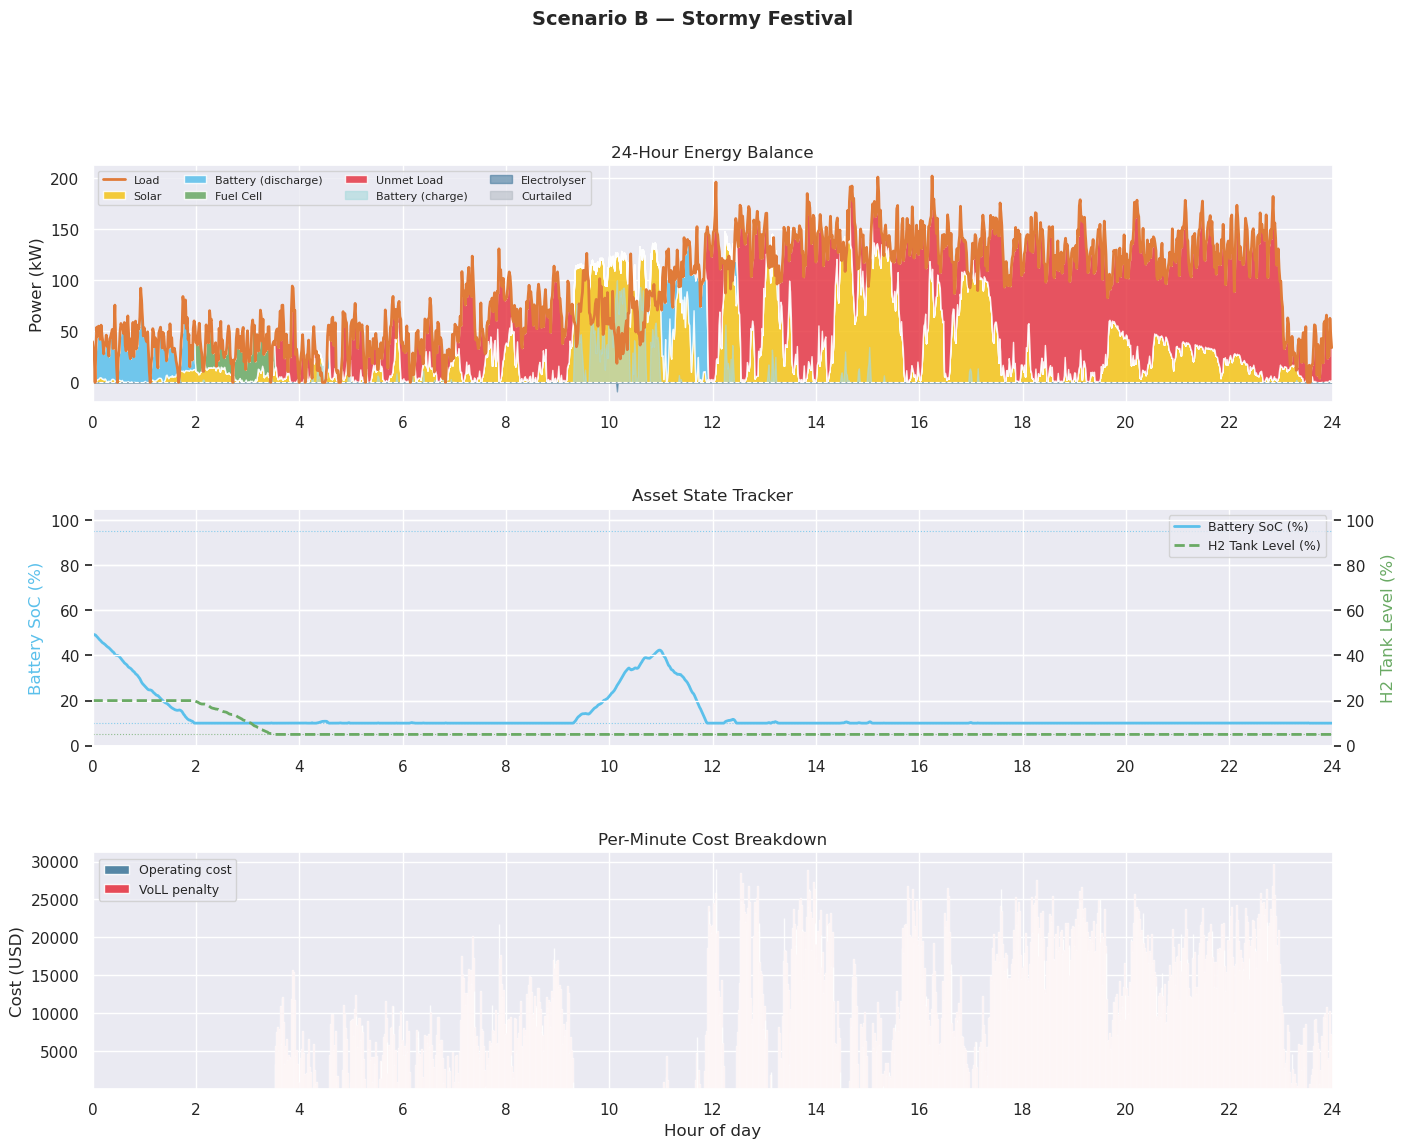


  FINANCIAL SUMMARY  —  Scenario B
  Battery degradation cost  : $     11.95
  Fuel cell dispatch cost   : $      4.51
  Electrolyser run cost     : $      0.00
  ────────────────────────────────────────────
  Subtotal operating cost   : $     16.46
  VoLL penalty (blackouts)  : $12,694,559.79
  TOTAL COST                : $12,694,576.25
  ────────────────────────────────────────────
  Energy curtailed          :       0.00 kWh
  Unmet energy (blackout)   :    1269.46 kWh
  Blackout minutes          :        984 min



In [8]:
rng_b   = np.random.default_rng(2)
load_b  = generate_event_load(peak_demand=LOAD_PEAK_KW * 1.15, volatility=15.0, rng=rng_b)
solar_b = generate_solar_profile(
    array_capacity=SOLAR_CAPACITY_KW, cloudiness=0.55, cloud_sigma=0.35, rng=rng_b
)

df_b     = run_simulation(load_b, solar_b)
plot_results(df_b, 'Scenario B — Stormy Festival')
summary_b = financial_summary(df_b, 'Scenario B')

---
### Scenario C — System Catastrophe

Load exceeds total system capacity. Battery and H2 tank deplete entirely. Algorithm flags exact blackout timestamps and calculates the VoLL financial penalty.

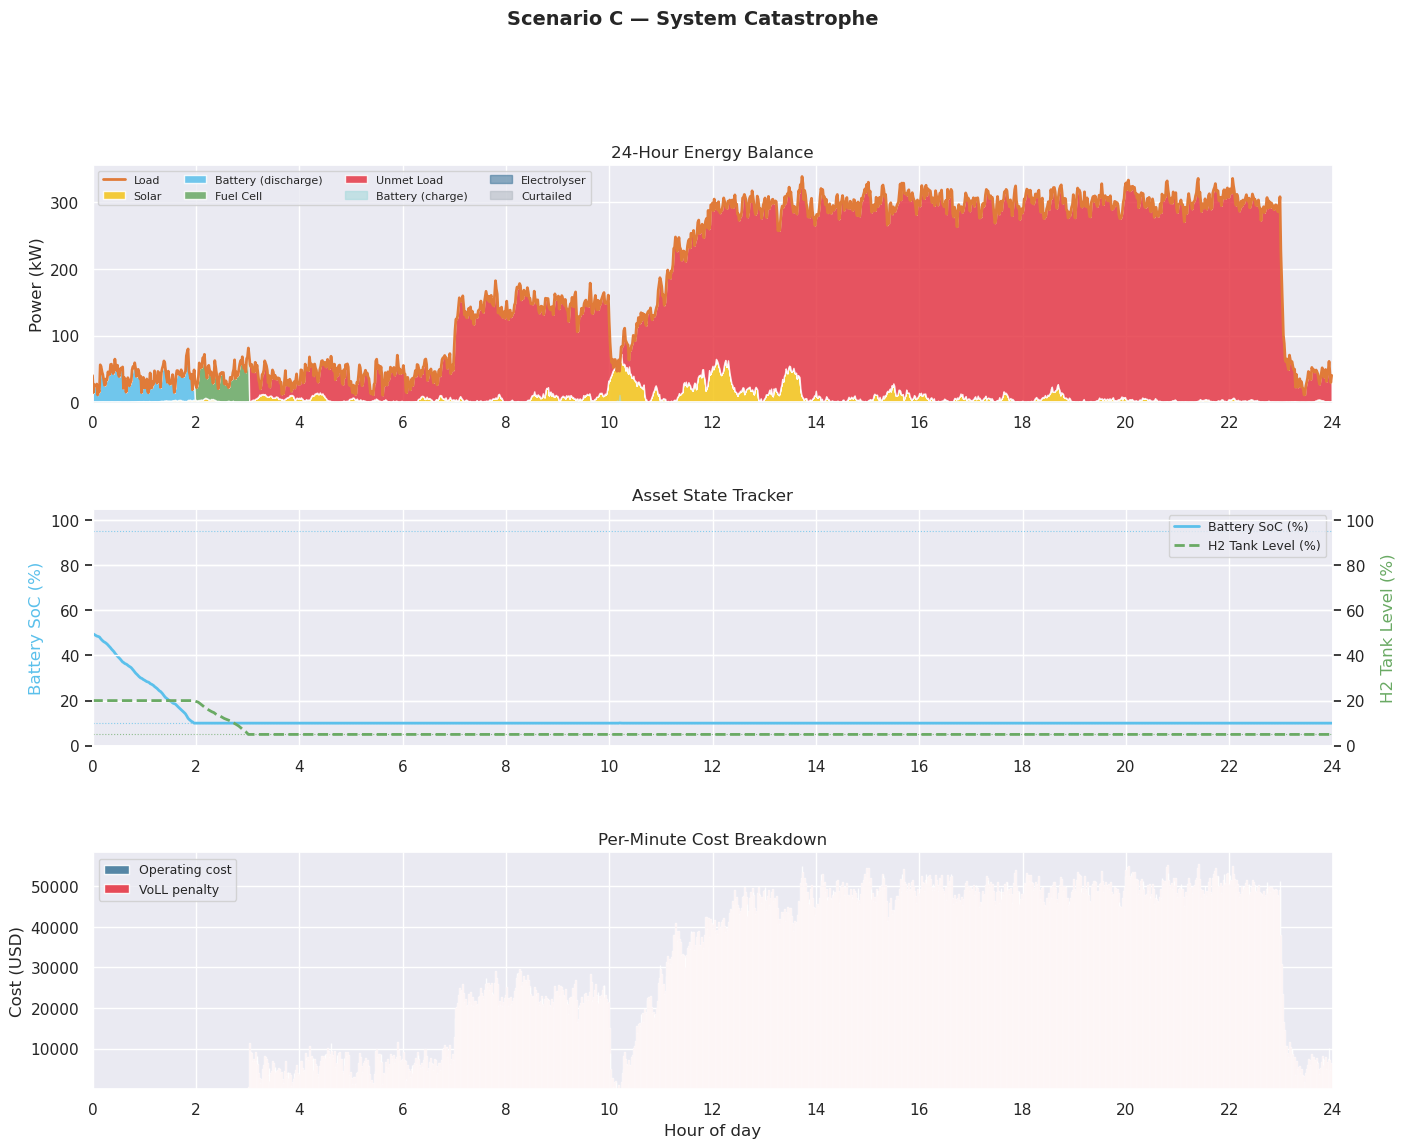


  FINANCIAL SUMMARY  —  Scenario C
  Battery degradation cost  : $      3.70
  Fuel cell dispatch cost   : $      4.50
  Electrolyser run cost     : $      0.00
  ────────────────────────────────────────────
  Subtotal operating cost   : $      8.20
  VoLL penalty (blackouts)  : $41,086,673.27
  TOTAL COST                : $41,086,681.47
  ────────────────────────────────────────────
  Energy curtailed          :       0.00 kWh
  Unmet energy (blackout)   :    4108.67 kWh
  Blackout minutes          :       1256 min

First/last 10 blackout minutes (1256 total):


,Hour,Unmet Load (kW),Batt SoC,H2 LoH
181,3.016667,3.136431,0.1,0.05
182,3.033333,67.862743,0.1,0.05
183,3.050000,55.025311,0.1,0.05
184,3.066667,50.706357,0.1,0.05
185,3.083333,53.662767,0.1,0.05
186,3.100000,41.840874,0.1,0.05
187,3.116667,43.989321,0.1,0.05
188,3.133333,41.467239,0.1,0.05
189,3.150000,54.808732,0.1,0.05
190,3.166667,41.798868,0.1,0.05


In [9]:
rng_c   = np.random.default_rng(3)
load_c  = generate_event_load(peak_demand=LOAD_PEAK_KW * 2.5, volatility=10.0, rng=rng_c)
solar_c = generate_solar_profile(
    array_capacity=SOLAR_CAPACITY_KW, cloudiness=0.90, cloud_sigma=0.1, rng=rng_c
)

df_c     = run_simulation(load_c, solar_c)
plot_results(df_c, 'Scenario C — System Catastrophe')
summary_c = financial_summary(df_c, 'Scenario C')

# Blackout timestamps
blackout_df = df_c[df_c['p_unmet'] > 0.1][['time', 'p_unmet', 'soc', 'loh']].copy()
blackout_df.columns = ['Hour', 'Unmet Load (kW)', 'Batt SoC', 'H2 LoH']
print(f'First/last 10 blackout minutes ({len(blackout_df)} total):')
display(pd.concat([blackout_df.head(10), blackout_df.tail(10)]))

---
### Cross-Scenario Comparison

,Total Cost ($),Batt Degradation ($),Fuel Cell ($),Electrolyser ($),VoLL Penalty ($),Curtailed (kWh),Unmet (kWh),Blackout (min)
scenario,,,,,,,,
Scenario A,2114840.51,21.76,7.97,1.65,2114809.13,0.11,211.48,190.00
Scenario B,12694576.25,11.95,4.51,0.00,12694559.79,0.00,1269.46,984.00
Scenario C,41086681.47,3.70,4.50,0.00,41086673.27,0.00,4108.67,1256.00


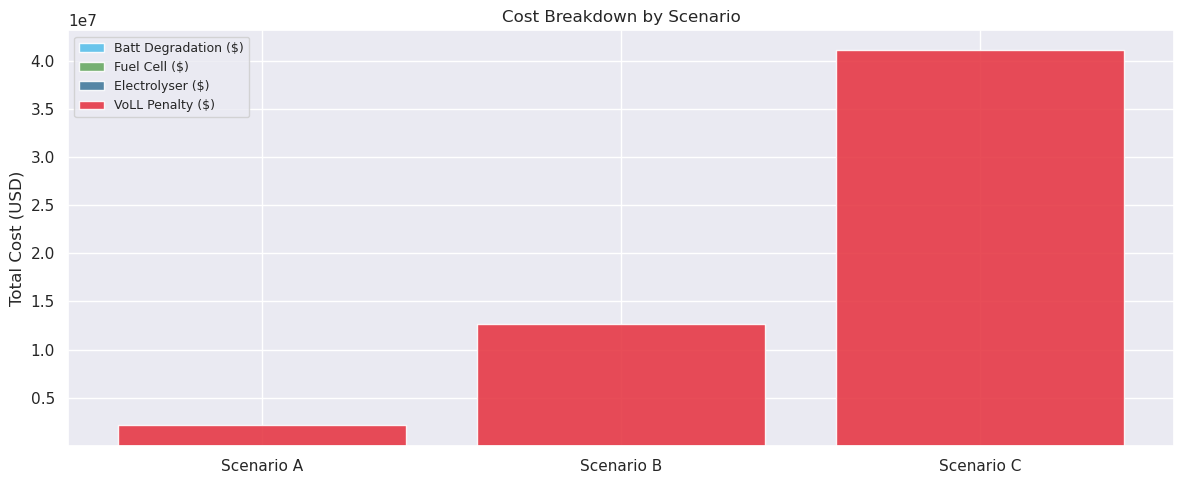

In [10]:
comparison = pd.DataFrame([summary_a, summary_b, summary_c]).set_index('scenario')
comparison.rename(columns={
    'total_cost':       'Total Cost ($)',
    'batt_deg':         'Batt Degradation ($)',
    'fc_cost':          'Fuel Cell ($)',
    'el_cost':          'Electrolyser ($)',
    'voll_penalty':     'VoLL Penalty ($)',
    'curtailed_kwh':    'Curtailed (kWh)',
    'unmet_kwh':        'Unmet (kWh)',
    'blackout_minutes': 'Blackout (min)',
}, inplace=True)

display(
    comparison.style
    .format('{:.2f}')
    .background_gradient(cmap='RdYlGn_r',
                         subset=['Total Cost ($)', 'VoLL Penalty ($)', 'Unmet (kWh)'])
)

# Cost waterfall
fig, ax = plt.subplots(figsize=(12, 5))
scenarios  = ['Scenario A', 'Scenario B', 'Scenario C']
cost_cols  = ['Batt Degradation ($)', 'Fuel Cell ($)', 'Electrolyser ($)', 'VoLL Penalty ($)']
colors     = ['#5bc0eb', '#6aaa64', '#457b9d', '#e63946']
bottom     = np.zeros(3)
for col, color in zip(cost_cols, colors):
    vals = comparison[col].values.astype(float)
    ax.bar(scenarios, vals, bottom=bottom, color=color, label=col, alpha=0.9)
    bottom += vals
ax.set_ylabel('Total Cost (USD)')
ax.set_title('Cost Breakdown by Scenario')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()